# Correlation analysis: HR features vs. Frustrated

This notebook is a dedicated correlation analysis for the 6 heart-rate (HR) features against the
binary frustration label `Frustrated_binary` (threshold = 3 on the 0-8 `Frustrated` scale), used
by `logistic_regression_training.ipynb`, `decision_tree_training.ipynb`, and `ANN_training.ipynb`.

We look at two versions of the HR features:

1. **Raw** HR features, as they appear in `HR_data.csv`.
2. **Per-individual normalized** HR features (z-scored within each individual), which is what the
   logistic regression and ANN pipelines actually train on.

For each version we show a **correlation matrix heatmap** (annotated) of all 6 HR features plus
`Frustrated`, and a **ranked bar chart** of each HR feature's correlation with `Frustrated`, sorted
from strongest to weakest. This puts the external (Gemini) feature ranking, based on raw
correlations, in context against the within-person signal the model notebooks actually rely on.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

sns.set_style('darkgrid')
sns.set_theme(font_scale=1.)

df = pd.read_csv("HR_data.csv", index_col=0)

threshold = 3  # same threshold as the model notebooks
df["Frustrated_binary"] = (df["Frustrated"] >= threshold).astype(int)

hr_feature_cols = ["HR_Mean", "HR_Median", "HR_std", "HR_Min", "HR_Max", "HR_AUC"]
df.head()

,HR_Mean,HR_Median,HR_std,HR_Min,HR_Max,HR_AUC,Round,Phase,Individual,Puzzler,Frustrated,Cohort,Frustrated_binary
0,77.965186,78.00,3.345290,73.23,83.37,22924.945,round_3,phase3,1,1,1,D1_1,0
1,70.981097,70.57,2.517879,67.12,78.22,21930.400,round_3,phase2,1,1,5,D1_1,1
2,73.371959,73.36,3.259569,67.88,80.22,21647.085,round_3,phase1,1,1,0,D1_1,0
3,78.916822,77.88,4.054595,72.32,84.92,25258.905,round_2,phase3,1,1,1,D1_1,0
4,77.322226,74.55,6.047603,70.52,90.15,23890.565,round_2,phase2,1,1,5,D1_1,1


## 1. Raw correlation analysis

The HR features here are exactly as measured (not normalized in any way).

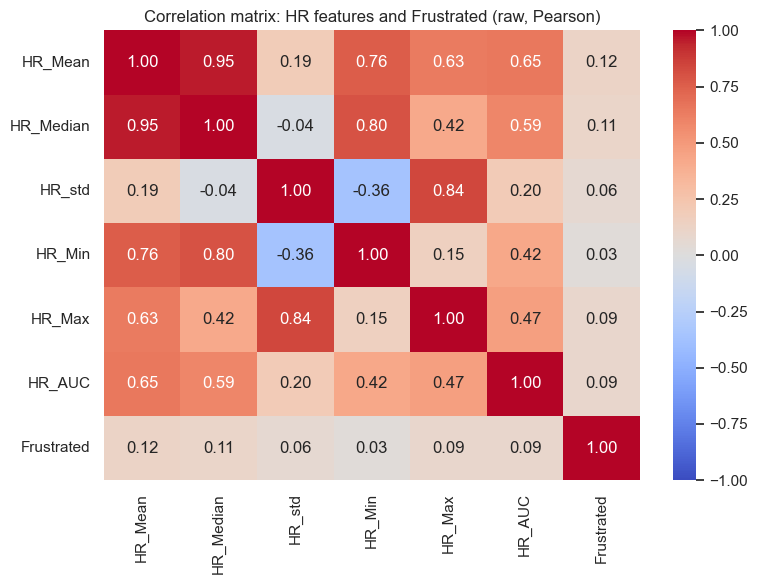

In [2]:
corr_raw = df[hr_feature_cols + ["Frustrated"]].corr(method="pearson")

plt.figure(figsize=(8, 6))
sns.heatmap(corr_raw, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix: HR features and Frustrated (raw, Pearson)")
plt.tight_layout()
plt.show()

Raw Spearman correlation with Frustrated (sorted strongest to weakest):
HR_Max       0.180681
HR_std       0.179403
HR_AUC       0.168586
HR_Mean      0.123036
HR_Median    0.089125
HR_Min      -0.002497
dtype: float64


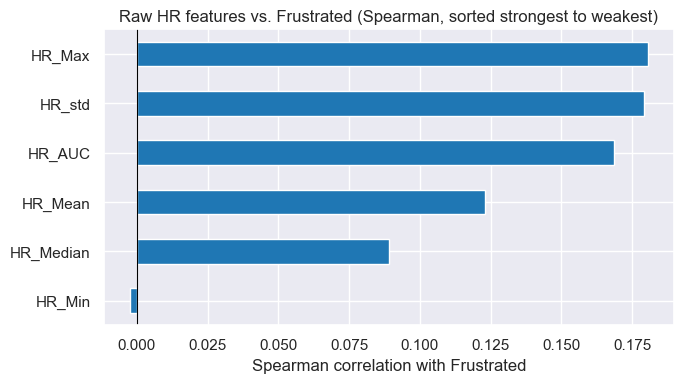

In [3]:
raw_corr = pd.Series(
    {col: spearmanr(df[col], df["Frustrated"]).correlation for col in hr_feature_cols}
).sort_values(ascending=False)

print("Raw Spearman correlation with Frustrated (sorted strongest to weakest):")
print(raw_corr)

plt.figure(figsize=(7, 4))
raw_corr.plot(kind="barh", color="tab:blue")
plt.gca().invert_yaxis()
plt.xlabel("Spearman correlation with Frustrated")
plt.title("Raw HR features vs. Frustrated (Spearman, sorted strongest to weakest)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

**Note:** these raw Spearman correlations are what an external (Gemini) analysis of this dataset
used to recommend `HR_Max`, `HR_std`, `HR_AUC` and `HR_Mean` as the strongest features (with
`HR_Median`/`HR_Min` as noise) — the ranking and values above closely match that recommendation
(`HR_Max` ~0.18, `HR_std` ~0.18, `HR_AUC` ~0.17, `HR_Mean` ~0.12, `HR_Median` ~0.09, `HR_Min` ~0.00).

## 2. Per-individual normalized correlation analysis

Resting heart rate and heart-rate variability differ a lot from person to person. The logistic
regression and ANN notebooks therefore z-score-normalize each HR feature **per individual** (subtract
that person's own mean, divide by their own std) before doing anything else. We repeat the
correlation analysis on these normalized features, since this is what those pipelines actually see.

In [4]:
df_norm = df.copy()
for col in hr_feature_cols:
    df_norm[col] = df.groupby("Individual")[col].transform(lambda s: (s - s.mean()) / s.std())

df_norm[hr_feature_cols].describe()

,HR_Mean,HR_Median,HR_std,HR_Min,HR_Max,HR_AUC
count,1.680000e+02,1.680000e+02,1.680000e+02,1.680000e+02,1.680000e+02,1.680000e+02
mean,6.079793e-17,-1.059999e-15,-3.700743e-17,1.073216e-15,-5.709718e-16,-6.079793e-17
std,9.602894e-01,9.602894e-01,9.602894e-01,9.602894e-01,9.602894e-01,9.602894e-01
min,-2.090416e+00,-2.320427e+00,-1.561129e+00,-2.182425e+00,-1.751144e+00,-1.571144e+00
25%,-7.280204e-01,-7.704507e-01,-6.933782e-01,-6.394762e-01,-7.559462e-01,-6.944055e-01
50%,-2.775503e-02,-8.617163e-02,-3.165731e-01,-2.825492e-02,-2.086793e-01,-2.577854e-01
75%,6.248084e-01,6.679727e-01,5.324870e-01,7.243773e-01,5.103417e-01,5.597943e-01
max,2.091565e+00,2.416027e+00,2.897812e+00,2.161078e+00,2.546851e+00,2.937623e+00


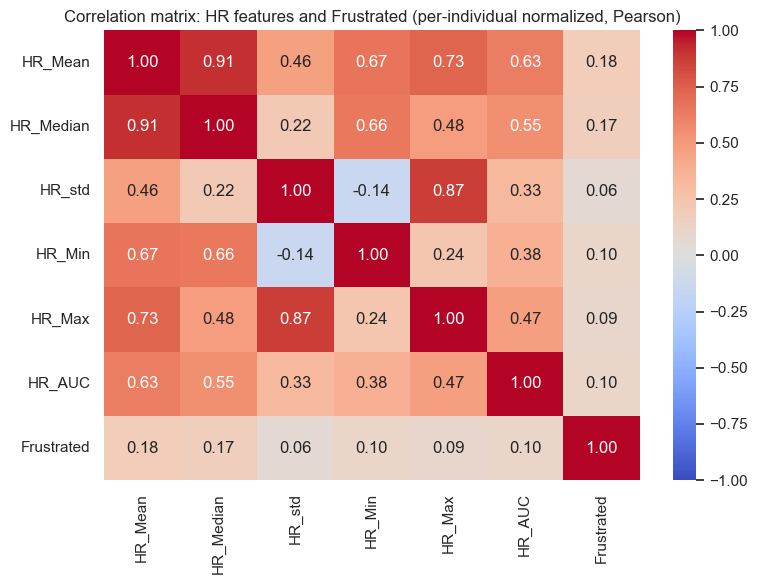

In [5]:
corr_norm = df_norm[hr_feature_cols + ["Frustrated"]].corr(method="pearson")

plt.figure(figsize=(8, 6))
sns.heatmap(corr_norm, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix: HR features and Frustrated (per-individual normalized, Pearson)")
plt.tight_layout()
plt.show()

Per-individual normalized Spearman correlation with Frustrated (sorted strongest to weakest):
HR_Mean      0.175732
HR_Median    0.157491
HR_AUC       0.145844
HR_Max       0.107842
HR_std       0.086632
HR_Min       0.066574
dtype: float64


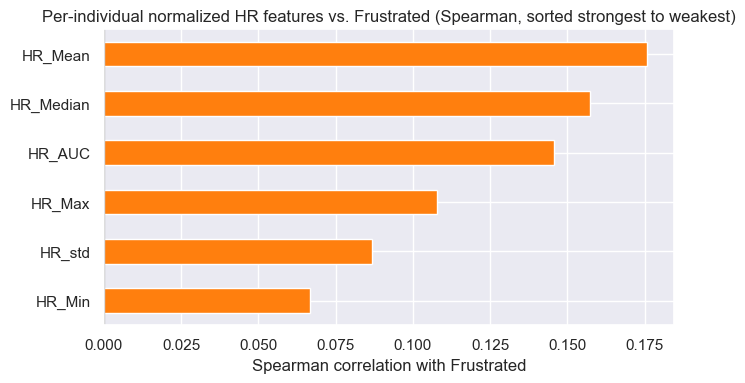

In [6]:
norm_corr = pd.Series(
    {col: spearmanr(df_norm[col], df_norm["Frustrated"]).correlation for col in hr_feature_cols}
).sort_values(ascending=False)

print("Per-individual normalized Spearman correlation with Frustrated (sorted strongest to weakest):")
print(norm_corr)

plt.figure(figsize=(7, 4))
norm_corr.plot(kind="barh", color="tab:orange")
plt.gca().invert_yaxis()
plt.xlabel("Spearman correlation with Frustrated")
plt.title("Per-individual normalized HR features vs. Frustrated (Spearman, sorted strongest to weakest)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## 3. Why do the rankings differ, and which one matters?

The **raw** correlations (Section 1) mostly capture **between-person** differences: someone with a
naturally higher resting heart rate, or more heart-rate variability overall, will tend to have higher
raw `HR_Max`/`HR_std`/`HR_AUC` *and* may happen to report more frustration on average. This is the
signal the external (Gemini) recommendation is based on.

The **per-individual normalized** correlations (Section 2) remove that between-person baseline and
isolate the **within-person** signal: for a *given* person, is *this* measurement higher or lower
than *their own* normal level, and does that relate to *their* frustration? This is the signal that
generalizes to a new, unseen individual (given a short calibration/baseline period) — and it's what
the logistic regression and ANN pipelines actually train on after Section 3 of those notebooks.

Under normalization, `HR_Mean` (and `HR_Median`) move to the top, while `HR_Max`/`HR_std` — the
external recommendation's top picks — drop to the weakest. `HR_Min` is consistently the weakest or
near-weakest feature in both the raw and normalized rankings.

**Conclusion:** based on this analysis, all three model notebooks (logistic regression, decision
tree, ANN) use the same fixed set of **5 HR features** — `HR_Mean`, `HR_Median`, `HR_std`, `HR_Max`,
`HR_AUC` — and drop `HR_Min`, which is the weakest predictor in both the raw and per-individual
normalized correlations. In addition, all three models include `Phase` and `Round` (one-hot
encoded) as features, so the results reported in `model_comparison.ipynb` reflect what these 5 HR
features, together with `Phase`/`Round`, can predict about self-reported frustration.